# Predictive Maintenance 

## MLE - Bayes theorem

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from scipy.stats import randint
from scipy.stats import norm

import os

* Predictive Maintenance data file path

In [2]:
homedir=os.environ['HOME'] + '/'
datapath=homedir + 'datasets/'
predmaint="predictive_maintenance.csv"

* Create Pandas data frame

In [3]:
pmfile=f"{datapath}{predmaint}"
pm_data = pd.read_csv(pmfile)

* Column data extraction for specific parameters

In [4]:
# Extract specific columns
air_temp = pm_data['Air temperature [K]'].values
pro_temp = pm_data['Process temperature [K]'].values
rot_speed = pm_data['Rotational speed [rpm]'].values

# Display first few rows
print(air_temp[:10])
print(pro_temp[:10])
print(rot_speed[:10])

[298.1 298.2 298.1 298.2 298.2 298.1 298.1 298.1 298.3 298.5]
[308.6 308.7 308.5 308.6 308.7 308.6 308.6 308.6 308.7 309. ]
[1551 1408 1498 1433 1408 1425 1558 1527 1667 1741]


* Histogram data for the parameters

Text(0.5, 1.0, 'Histograms of Sensor Data')

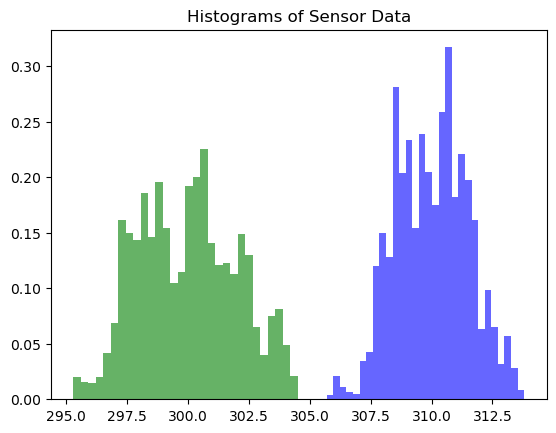

In [5]:
plt.hist(air_temp, bins=30, density=True, alpha=0.6, color='g')
plt.hist(pro_temp, bins=30, density=True, alpha=0.6, color='b')
#plt.hist(rot_speed, bins=30, density=True, alpha=0.6, color='b')
plt.title('Histograms of Sensor Data')


### Two classes - Target = 0, Target = 1

In [6]:
c0 = pm_data[pm_data['Target'] == 0]
c1 = pm_data[pm_data['Target'] == 1]

### Get data corresponding to features
  - Air Temperature
  - Process Temperature
  - Rotational Speed

### feature data for class c0

In [7]:
c0_airtemp = c0['Air temperature [K]'].values
c0_proctemp = c0['Process temperature [K]'].values
c0_rotspeed = c0['Rotational speed [rpm]'].values

### feature data for class c1

In [8]:
c1_airtemp = c1['Air temperature [K]'].values
c1_proctemp = c1['Process temperature [K]'].values
c1_rotspeed = c1['Rotational speed [rpm]'].values

### Define a function which 
* Fit `Gaussian` function to the feature
* Arguments to the function
  - feature array corresponding to the class (c0, c1)
  - Labels used for plots

In [9]:
def gaussian_pdf(x, mu, sigma):
    return (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-((x-mu)**2)/(2*sigma**2))

In [10]:
def compute_gaussian_pdf(ftr_data):
    ftr_data_mu = np.mean(ftr_data)
    ftr_data_sigma = np.std(ftr_data)
    x = np.linspace(min(ftr_data), max(ftr_data), 1000)

    pdf_ftr = gaussian_pdf(x, ftr_data_mu, ftr_data_sigma)
    
    return x, pdf_ftr

In [11]:
def plot_histograms(ftr_data, title_str, xlabel_str, ylable_str, color='tab:blue'):
    x_ftr, pdf_ftr = compute_gaussian_pdf(ftr_data)
    plt.figure()
    plt.hist(ftr_data, bins=40, density=True, alpha=0.4, color=color)
    plt.plot(x_ftr, pdf_ftr)
    plt.title(title_str)
    plt.xlabel(xlabel_str)
    plt.ylabel(ylable_str)
    plt.show()

### For class c0, fit `Gaussian` function to `Air Temperature`

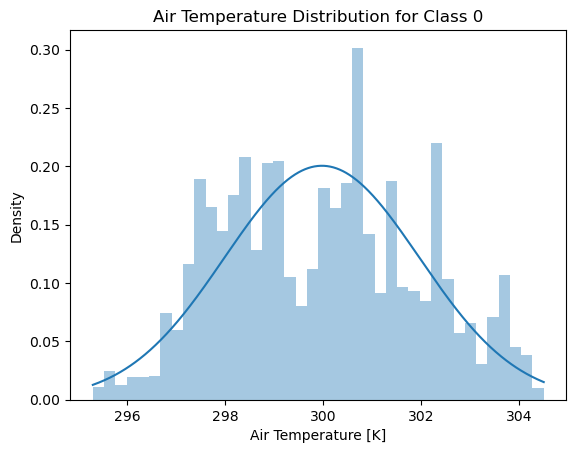

In [12]:
plot_histograms(c0_airtemp, 'Air Temperature Distribution for Class 0', 'Air Temperature [K]', 'Density')

### For class c1, fit `Gaussian` function to `Air Temperature`

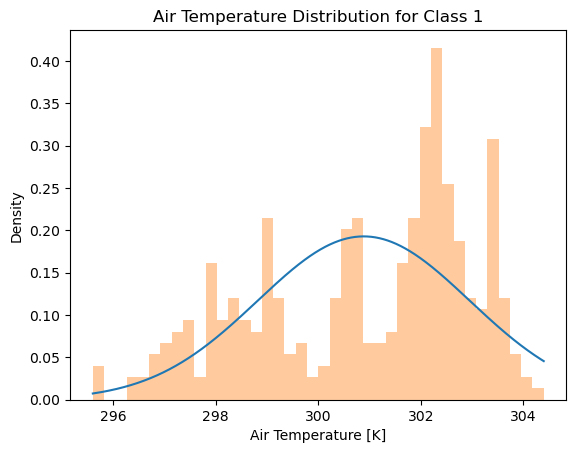

In [13]:
plot_histograms(c1_airtemp, 'Air Temperature Distribution for Class 1', 'Air Temperature [K]', 'Density', "tab:orange")

### For class c0, fit `Gaussian` function to `Process Temperature`

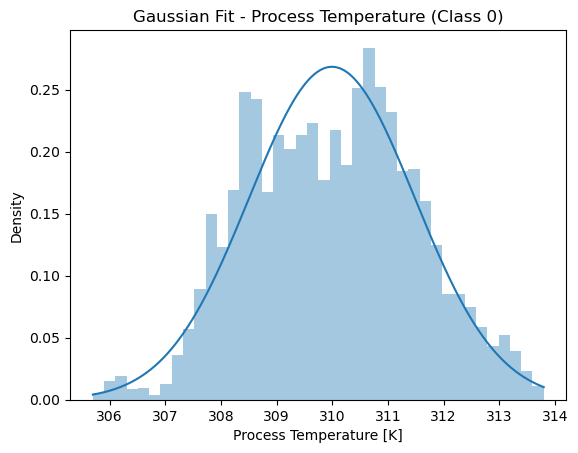

In [14]:
plot_histograms(c0_proctemp, 'Gaussian Fit - Process Temperature (Class 0)', 'Process Temperature [K]', 'Density')

### For class c1, fit `Gaussian` function to `Process Temperature`

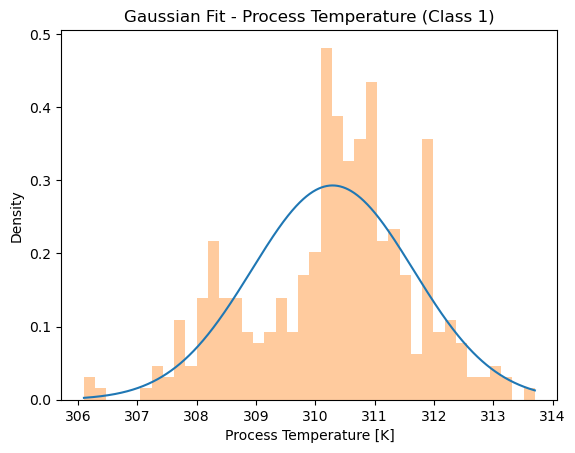

In [15]:
plot_histograms(c1_proctemp, 'Gaussian Fit - Process Temperature (Class 1)', 
                'Process Temperature [K]', 'Density', color='tab:orange')

### For class c0, fit `Gaussian` function to `Rotational Speed`

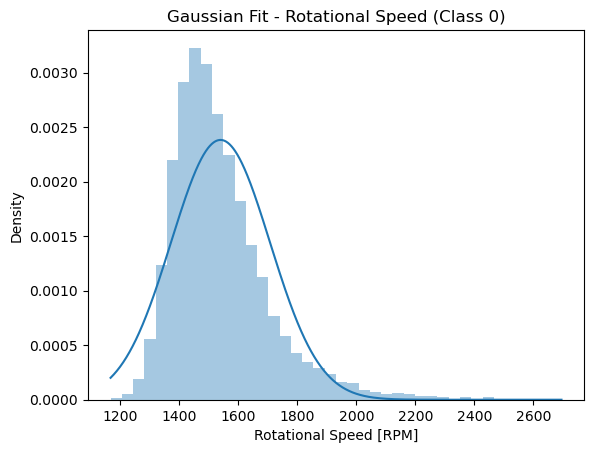

In [16]:
plot_histograms(c0_rotspeed, 'Gaussian Fit - Rotational Speed (Class 0)', 'Rotational Speed [RPM]', 'Density')

### For class c1, fit `Gaussian` function to `Rotational Speed`

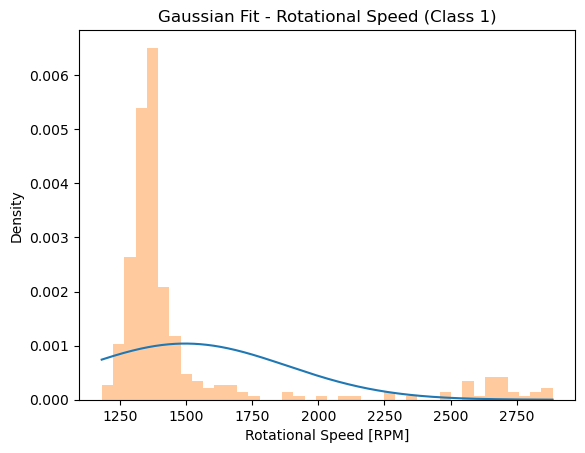

In [17]:
plot_histograms(c1_rotspeed, 'Gaussian Fit - Rotational Speed (Class 1)', 
                'Rotational Speed [RPM]', 'Density', color='tab:orange')

### Naive Bayes Classifiers - reference
* https://www.geeksforgeeks.org/machine-learning/naive-bayes-classifiers/
* https://www.geeksforgeeks.org/machine-learning/gaussian-naive-bayes/
* Compute probability of class, C_i (i `E` {0, 1}) given feature set X_j ( j `E` { 1, 2 .. n}) 
  - P(C_i|X) = P(X|C_i).P(C_i)/P(X)
    * P(C_i|X) : Posterior Probability
    * P(X|C_i) : Likelihood of Features X given Class C_i
    * P(C_i) : Prior Probability
    * P(X) : Marginal likelihood or Evidence


### Prior Probabilities of Class C_i (i `E` {0,1})

In [18]:
# Prior probabilities of classes C_0 and C_1
y1 = pm_data['Target'].values
classes, counts = np.unique(y1, return_counts=True)
priors = counts / len(y1)
print(f"classes: {classes}, counts: {counts}, priors: {priors}")

classes: [0 1], counts: [9661  339], priors: [0.9661 0.0339]


### Naive Bayes Classwise `[mu, std]` for selected features

In [19]:
# mean and std for class 0
c0_mu = c0[['Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]']].mean().values
c0_sigma = c0[['Air temperature [K]',
                'Process temperature [K]',
                'Rotational speed [rpm]']].std().values

# mean and std for class 1
c1_mu = c1[['Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]']].mean().values
c1_sigma = c1[['Air temperature [K]',
                'Process temperature [K]',
                'Rotational speed [rpm]']].std().values

### Calculate `Gaussian PDF` for test data 
* test_data is an array `< Air Temp, Process Temp, Rot Speed >`

In [20]:
def naive_bayes_predict(test_data, c0_mu, c0_sigma, c1_mu, c1_sigma, priors):
    # Calculate likelihood for class 0
    likelihood_c0 = np.prod(gaussian_pdf(test_data, c0_mu, c0_sigma))
    posterior0 = likelihood_c0 * priors[0]
    
    # Calculate likelihood for class 1
    likelihood_c1 = np.prod(gaussian_pdf(test_data, c1_mu, c1_sigma))
    posterior1 = likelihood_c1 * priors[1]

    # Assuming equal priors
    if posterior1 > posterior0:
        return 1, posterior0, posterior1
    else:
        return 0, posterior0, posterior1

### Test the Naive Bayes classifier with sample data

In [21]:
new_record = np.array([300, 310, 1700])   # [Air Temp, Process Temp, Rot Speed]
pred_class, post0, post1 = naive_bayes_predict(new_record, c0_mu, c0_sigma, c1_mu, c1_sigma, priors)
print(f"Predicted Class: {pred_class}, Posterior C0: {post0}, Posterior C1: {post1}")

Predicted Class: 0, Posterior C0: 7.851409710372898e-05, Posterior C1: 1.5354779245967973e-06


### Machine Learning - split the test data {Training Data, Test Data}
* X is the `feature matrix` and y is the `target vector`

In [22]:
from sklearn.model_selection import train_test_split

X = pm_data[['Air temperature [K]',
           'Process temperature [K]',
           'Rotational speed [rpm]']].values

y = pm_data['Target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

### Classify feature rows based on Target class 0 or 1

In [23]:
X_train_c0 = X_train[y_train == 0]
X_train_c1 = X_train[y_train == 1]

# P(C_0) and P(C_1) from training data
priors_train = np.array([len(X_train_c0)/len(X_train), 
                         len(X_train_c1)/len(X_train)])
train_mu0 = X_train_c0.mean(axis=0)
train_sigma0 = X_train_c0.std(axis=0)

train_mu1 = X_train_c1.mean(axis=0)
train_sigma1 = X_train_c1.std(axis=0)


### Use `Naive-Bayes` predictor for `classification` of the Test Data

In [ ]:
y_pred = []

# naive_bayes_predict returns a tuple (predicted_class, posterior0, posterior1)
# so we take the first element [0] which is the predicted class label
y_pred = np.array([naive_bayes_predict(X_test[i], train_mu0, 
                        train_sigma0, train_mu1, train_sigma1, priors_train)[0] for i in range(len(X_test))])

y_pred = np.array(y_pred)
print(y_pred)

[0 0 0 ... 0 1 0]


### Confusion Matrix
* Performance of classification model 
* Predictions made by the model vs actual results<br>
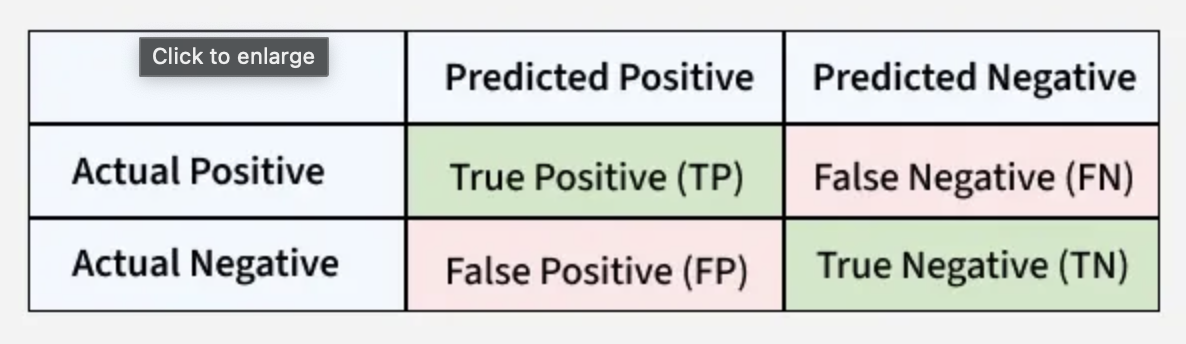

In [30]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[1919   20]
 [  56    5]]


### Accuracy Score 
* Shows number of predictions which the model got right out of all the predictions
* Calculation<br>
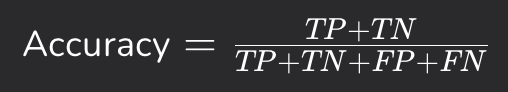 

In [29]:
from sklearn.metrics import accuracy_score
ac_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {ac_score}")

Accuracy: 0.962


In [31]:
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1939
           1       0.20      0.08      0.12        61

    accuracy                           0.96      2000
   macro avg       0.59      0.54      0.55      2000
weighted avg       0.95      0.96      0.95      2000

